Initial waist w0           = 2.000000e-05 m
Propagation distance z     = 5.000000e-03 m
Analytical waist w(z)      = 8.205226e-05 m
Numerical estimated w(z)   = 8.205211e-05 m


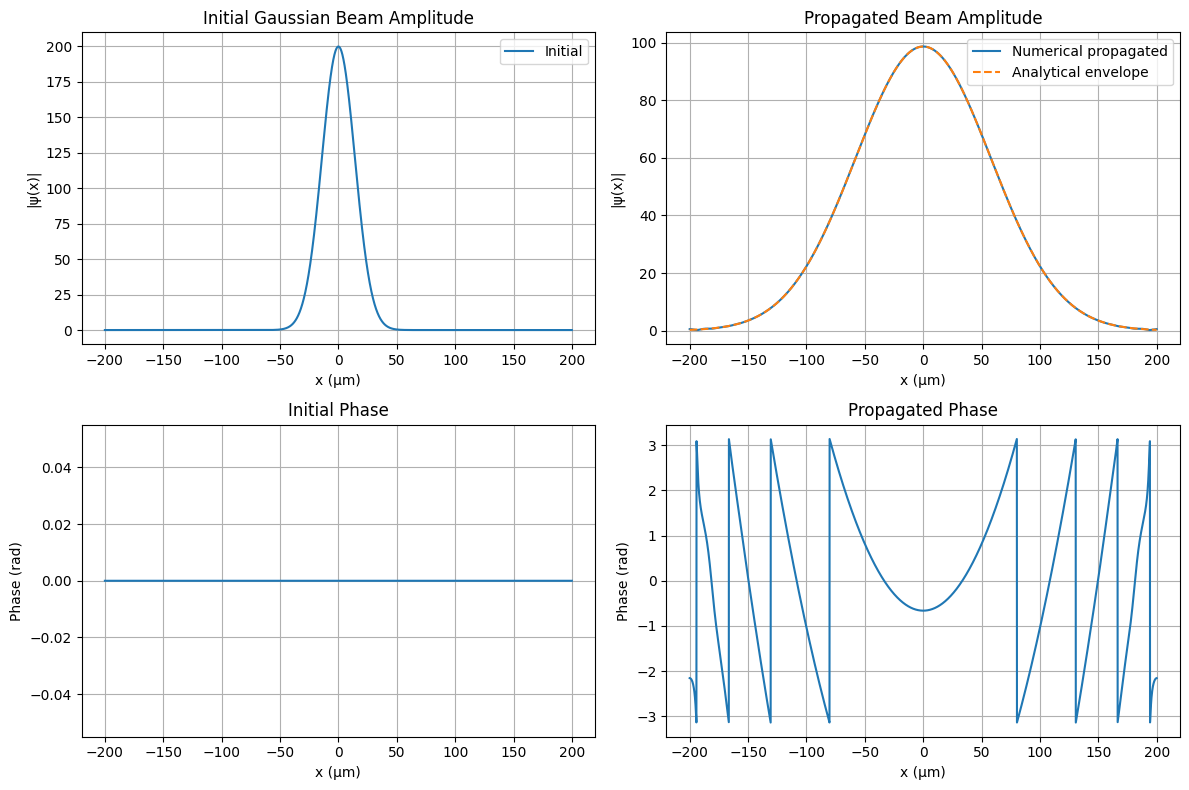

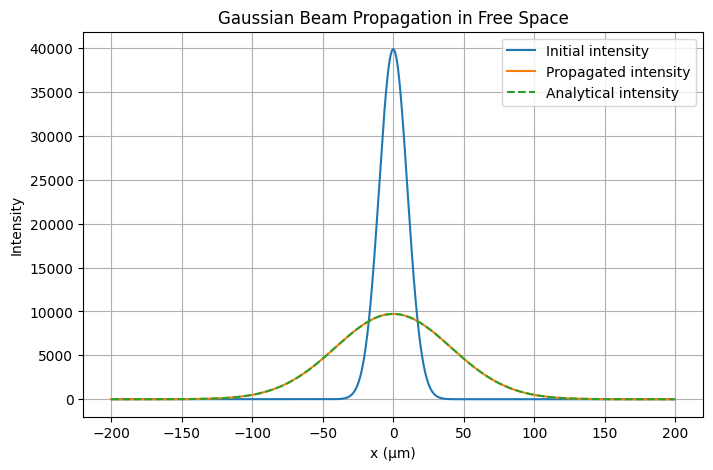

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Parameters
# -----------------------------
wavelength = 1.0e-6          # meters
w0 = 20e-6                   # initial beam waist (meters)
z = 5e-3                     # propagation distance (meters)

# Spatial grid
Lx = 400e-6                  # total transverse window size (meters)
N = 2**12                    # number of spatial points
dx = Lx / N                  # spatial resolution

x = np.linspace(-Lx / 2, Lx / 2, N, endpoint=False)

k0 = 2 * np.pi / wavelength


# -----------------------------
# Initial Gaussian beam
# -----------------------------
def gaussian_beam(x: np.ndarray, w0: float) -> np.ndarray:
    """
    Initial Gaussian field amplitude at z=0.
    """
    return np.exp(-(x**2) / (w0**2)).astype(np.complex128)


psi0 = gaussian_beam(x, w0)

# Normalize
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx)


# -----------------------------
# Free-space propagation
# -----------------------------
def propagate_free_space(
    psi_x: np.ndarray,
    dx: float,
    wavelength: float,
    z: float
) -> np.ndarray:
    """
    Propagate a 1D wavefield through free space using Fourier optics.

    Steps:
    1. FFT to momentum/spatial-frequency domain
    2. Apply quadratic propagation phase
    3. IFFT back to position domain
    """
    N = len(psi_x)

    # Spatial frequency grid (cycles/m)
    fx = np.fft.fftfreq(N, d=dx)

    # Angular spatial frequency
    kx = 2 * np.pi * fx

    # Paraxial free-space propagator:
    # exp(-i * kx^2 * z / (2*k0))
    k0 = 2 * np.pi / wavelength
    H = np.exp(-1j * (kx**2) * z / (2 * k0))

    psi_k = np.fft.fft(psi_x, norm="ortho")
    psi_k_prop = psi_k * H
    psi_out = np.fft.ifft(psi_k_prop, norm="ortho")

    return psi_out


psi_z = propagate_free_space(psi0, dx, wavelength, z)

# Normalize again to suppress tiny numerical drift
psi_z /= np.sqrt(np.sum(np.abs(psi_z)**2) * dx)


# -----------------------------
# Analytical Gaussian width
# -----------------------------
def gaussian_beam_width(w0: float, wavelength: float, z: float) -> float:
    """
    Analytical Gaussian beam radius after free-space propagation.
    """
    zR = np.pi * w0**2 / wavelength
    return w0 * np.sqrt(1 + (z / zR)**2)


wz_analytic = gaussian_beam_width(w0, wavelength, z)

# Analytical propagated Gaussian envelope (amplitude only, normalized)
psi_analytic = np.exp(-(x**2) / (wz_analytic**2)).astype(np.complex128)
psi_analytic /= np.sqrt(np.sum(np.abs(psi_analytic)**2) * dx)


# -----------------------------
# Beam width from numerical result
# -----------------------------
def second_moment_width(x: np.ndarray, psi: np.ndarray, dx: float) -> float:
    """
    Estimate beam width using second moment.
    For exp(-x^2 / w^2), this gives a quantity proportional to width.
    """
    intensity = np.abs(psi)**2
    mean_x = np.sum(x * intensity) * dx
    mean_x2 = np.sum((x**2) * intensity) * dx
    sigma2 = mean_x2 - mean_x**2

    # For Gaussian exp(-x^2 / w^2), intensity = exp(-2x^2/w^2)
    # sigma = w / 2  => w = 2*sigma
    return 2 * np.sqrt(max(sigma2, 0.0))


wz_numeric = second_moment_width(x, psi_z, dx)

print(f"Initial waist w0           = {w0:.6e} m")
print(f"Propagation distance z     = {z:.6e} m")
print(f"Analytical waist w(z)      = {wz_analytic:.6e} m")
print(f"Numerical estimated w(z)   = {wz_numeric:.6e} m")


# -----------------------------
# Plot amplitude and phase
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Initial amplitude
axes[0, 0].plot(x * 1e6, np.abs(psi0), label="Initial")
axes[0, 0].set_title("Initial Gaussian Beam Amplitude")
axes[0, 0].set_xlabel("x (µm)")
axes[0, 0].set_ylabel("|ψ(x)|")
axes[0, 0].grid(True)
axes[0, 0].legend()

# Propagated amplitude
axes[0, 1].plot(x * 1e6, np.abs(psi_z), label="Numerical propagated")
axes[0, 1].plot(x * 1e6, np.abs(psi_analytic), "--", label="Analytical envelope")
axes[0, 1].set_title("Propagated Beam Amplitude")
axes[0, 1].set_xlabel("x (µm)")
axes[0, 1].set_ylabel("|ψ(x)|")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Initial phase
axes[1, 0].plot(x * 1e6, np.angle(psi0))
axes[1, 0].set_title("Initial Phase")
axes[1, 0].set_xlabel("x (µm)")
axes[1, 0].set_ylabel("Phase (rad)")
axes[1, 0].grid(True)

# Propagated phase
axes[1, 1].plot(x * 1e6, np.angle(psi_z))
axes[1, 1].set_title("Propagated Phase")
axes[1, 1].set_xlabel("x (µm)")
axes[1, 1].set_ylabel("Phase (rad)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


# -----------------------------
# Intensity comparison
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(x * 1e6, np.abs(psi0)**2, label="Initial intensity")
plt.plot(x * 1e6, np.abs(psi_z)**2, label="Propagated intensity")
plt.plot(x * 1e6, np.abs(psi_analytic)**2, "--", label="Analytical intensity")
plt.xlabel("x (µm)")
plt.ylabel("Intensity")
plt.title("Gaussian Beam Propagation in Free Space")
plt.grid(True)
plt.legend()
plt.show()